# Solar Diameter and Sunspot Characterisation - the science notebook

This notebook answers the main science requirement of Lab 03: **measure the Sun's radio diameter from the extended-source interferometric response**. The sunspot analysis is kept, but it is treated as a secondary extension once the diameter result is secure.

Recap of the inputs:
- Notebooks 02a/02b loaded and DC-cleaned the raw visibility, flagged a chip-to-chip gain step, and quantified the rolling-median fringe attenuation with a synthetic injection test.
- Notebook 03 verified the expected fringe-frequency band and Bessel-null pattern from the lidar baseline prior.
- Notebook 04 calibrated the projected baseline axis and handed off an adopted `(B_EW, B_NS)` together with a realistic **30 cm** downstream uncertainty floor.

The workflow in this notebook is therefore:

1. carry forward the adopted baseline from notebook 04;
2. extract the fringe envelope;
3. measure the solar diameter three ways;
4. quote statistical, systematic, and total uncertainties;
5. only then turn to sunspot residuals as an extension.

For readability, treat the methods in this order:
- **Primary / lab-prescribed:** Method A (Bessel/null method) and Method C (modulating-function form of the same null-based logic).
- **Primary / stronger estimator:** Method B, the full-envelope Bessel fit. This is the adopted central value because it uses the whole envelope rather than only the zeros.
- **Extension:** the Fourier/Hilbert aside and the sunspot localisation sections.


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# -- local utilities ---------------------------------------------------------
sys.path.insert(0, str(Path("..").resolve()))
from utils import (
    # constants
    F_S_HZ, N_FFT, F_RF0_HZ, PLOT_BAND_GHZ,
    C_LIGHT_MS, OMEGA_EARTH_RAD_S, SIDEREAL_DAY_S,
    NCH_LAT_DEG, NCH_LON_DEG,
    NOMINAL_B_EW_M, NOMINAL_B_NS_M, NOMINAL_B_EW_ERR_M, NOMINAL_B_NS_ERR_M, BAD_CHANNELS,
    SOLAR_DIAMETER_ARCMIN_NOMINAL,
    # data loading
    load_processed_sun_chip_series,
    # geometry
    lst_deg, hour_angle_deg, hour_angle_rad,
    geometric_delay_s, sky_baseline_lambda,
    fringe_frequency_hz, fringe_period_s, x_coordinate,
    # fringe models
    FringeModelParams, SolarDiskParams, SunspotParams,
    point_source_visibility, point_source_fringes,
    uniform_disk_visibility_amplitude, uniform_disk_visibility_signed,
    uniform_disk_zeros, solar_visibility, fringe_envelope,
    # baseline fitting (unused — baseline loaded from pickle)
    BaselineResult,
    # solar analysis
    SolarDiameterResult, SunspotDetection,
    extract_fringe_envelope, find_bessel_zeros_in_envelope,
    solar_diameter_from_zeros, fit_solar_diameter_bessel,
    detect_sunspot_anomalies, localize_sunspot_phase, characterize_sunspot_flux,
    # plotting
    NEUTRAL_COLOR,
    SS_FINE, SS_STANDARD,
    LW_FINE, LW_LIGHT, LW_STANDARD,
    MS_FINE,
    ALPHA_EXTRA_LIGHT,
    TEXTWIDTH_IN, LABEL_SIZE, TICK_SIZE, LEGEND_SIZE, EMPHASIS_SIZE,
)

COMPONENT_COLORS = [f"C{i}" for i in range(10)]
from utils.plotter import (
    plot_fringe_model_comparison,
    plot_bessel_envelope_fit,
    plot_solar_diameter_summary,
    plot_sunspot_residuals,
)

%matplotlib inline
plt.rcParams.update({"figure.dpi": 130, "figure.facecolor": "white"})
print("Imports OK.")


Imports OK.


In [2]:
DATA_DIR = Path("../../../data/lab03/sun_calibration/chips")
chip_paths = sorted(DATA_DIR.glob("sun_calibration_chip_*.npz"))
print(f"Found {len(chip_paths)} chip files:")
for p in chip_paths:
    print(f"  {p.name}")

chip_data = load_processed_sun_chip_series(chip_paths)

Found 3 chip files:
  sun_calibration_chip_00.npz
  sun_calibration_chip_01.npz
  sun_calibration_chip_02.npz


In [3]:
# -------------------------------------------------------------------
# Unpack raw arrays
# -------------------------------------------------------------------
captures   = chip_data.captures          # CaptureSeries
corr_raw   = captures.corr              # (N_cap, N_CH) complex — raw visibility
corr_std   = captures.corr_std          # (N_cap, N_CH) float  — per-channel uncertainty
F_SKY_GHZ  = chip_data.f_sky_ghz        # (N_CH,) sky frequency in GHz
DF_HZ      = chip_data.df_hz            # channel spacing in Hz

# Timing and coordinates (pre-computed in chip export)
unix_mid   = captures.unix_mid          # (N_cap,) midpoint timestamps
ha_deg_arr = chip_data.ha_deg
ha_rad_arr = np.deg2rad(ha_deg_arr)
sun_ra     = chip_data.sun_ra_deg       # (N_cap,) Sun RA in degrees
sun_dec    = chip_data.sun_dec_deg      # (N_cap,) Sun Dec in degrees

# Chip boundaries
chip_slices = chip_data.chip_slices
N_chips = len(chip_slices)

# Derived quantities
F_SKY_HZ     = F_SKY_GHZ * 1e9
dec_rad_mean = np.deg2rad(np.nanmean(sun_dec))
dec_rad_arr  = np.deg2rad(sun_dec)            # per-capture declination
band_mask    = (F_SKY_GHZ >= PLOT_BAND_GHZ[0]) & (F_SKY_GHZ <= PLOT_BAND_GHZ[1])
band_center_hz = np.mean(F_SKY_HZ[band_mask])

# -------------------------------------------------------------------
# Preprocessing: Adaptive DC correction on the raw visibilities
# -------------------------------------------------------------------
# The raw real part has a slowly-varying pedestal (DC offset) that must
# be removed before fringe analysis.  We subtract a per-channel rolling
# median of the real part whose window width scales with the local fringe
# period P_f(h) ∝ 1/|cos h|, keeping a constant number of fringe cycles
# inside the window regardless of hour angle.
from utils import adaptive_real_dc_correction

DC_N_PERIODS       = 3.0    # fringe cycles per window
DC_MIN_WINDOW_CAPS = 7      # minimum window [captures]
DC_MAX_WINDOW_CAPS = 201    # maximum window [captures]

dc_result = adaptive_real_dc_correction(
    corr_chips=[corr_raw[sl] for sl in chip_slices],
    unix_chips=[unix_mid[sl] for sl in chip_slices],
    ha_rad_chips=[ha_rad_arr[sl] for sl in chip_slices],
    bad_channels=BAD_CHANNELS,
    b_ew=NOMINAL_B_EW_M,
    freq_hz=band_center_hz,
    dec_rad=dec_rad_mean,
    n_periods=DC_N_PERIODS,
    min_window_caps=DC_MIN_WINDOW_CAPS,
    max_window_caps=DC_MAX_WINDOW_CAPS,
)
corr_dc = dc_result.corr_dc  # (N_cap, N_CH) complex — DC-corrected, bad channels = NaN

print(f"Total captures:     {len(unix_mid)}")
print(f"Channels:           {len(F_SKY_GHZ)}  ({F_SKY_GHZ[0]:.3f} -- {F_SKY_GHZ[-1]:.3f} GHz)")
print(f"Analysis band:      {PLOT_BAND_GHZ[0]:.3f} -- {PLOT_BAND_GHZ[1]:.3f} GHz  ({band_mask.sum()} channels)")
print(f"Band centre:        {band_center_hz/1e9:.4f} GHz")
print(f"Mean Sun dec:       {np.rad2deg(dec_rad_mean):.3f} deg")
print(f"HA range:           {ha_deg_arr.min():.1f} to {ha_deg_arr.max():.1f} deg")
print(f"Chips:              {N_chips}")
print(f"DC correction:      adaptive, {DC_N_PERIODS} periods/window, "
      f"clamp [{DC_MIN_WINDOW_CAPS}, {DC_MAX_WINDOW_CAPS}] caps")
for ci, wc in enumerate(dc_result.window_caps_chips):
    print(f"  Chip {ci}: window range {wc.min()}–{wc.max()} captures")
print(f"Bad channels:       {list(BAD_CHANNELS)}")

Total captures:     8226
Channels:           1024  (10.290 -- 10.540 GHz)
Analysis band:      10.415 -- 10.485 GHz  (287 channels)
Band centre:        10.4499 GHz
Mean Sun dec:       -0.083 deg
HA range:           -79.9 to 22.0 deg
Chips:              3
DC correction:      adaptive, 3.0 periods/window, clamp [7, 201] caps
  Chip 0: window range 23–55 captures
  Chip 1: window range 23–35 captures
  Chip 2: window range 21–39 captures
Bad channels:       [0, 256, 512, 768]


In [4]:
# --- Apply per-chip gain correction from notebook 02a ---
# This makes the envelope amplitude (and hence the diameter fit) insensitive
# to the ~10% chip-to-chip gain step identified in notebook 02a.
import pickle as _pkl
from utils import apply_chip_gain_correction, CHIP_GAIN_RATIOS_DEFAULT

_sidecar = Path("_chip_gain_measured.pkl")
if _sidecar.exists():
    with open(_sidecar, "rb") as _f:
        _cal = _pkl.load(_f)
    chip_gains_measured = np.array(_cal["chip_gains_measured"])
    SIGMA_V_PER_CAPTURE = float(_cal["sigma_V_per_capture"])
    print(f"Loaded chip gains from 02a sidecar: {chip_gains_measured}")
else:
    chip_gains_measured = np.array(CHIP_GAIN_RATIOS_DEFAULT[:N_chips])
    SIGMA_V_PER_CAPTURE = 0.01
    print(f"[warning] 02a sidecar not found -- using default chip gains {chip_gains_measured}.")

corr_dc_gc = apply_chip_gain_correction(corr_dc, chip_slices, chip_gains_measured)
corr_dc = corr_dc_gc   # alias: downstream science code uses the corrected data
print("Chip-gain correction applied to corr_dc in place.")

# Also load the DC-correction amplitude ratio alpha from 02b for the error budget
_dc_sidecar = Path("_dc_correction_alpha.pkl")
if _dc_sidecar.exists():
    with open(_dc_sidecar, "rb") as _f:
        _dc_cal = _pkl.load(_f)
    DC_CORRECTION_ALPHA = float(_dc_cal["alpha"])
    print(f"Loaded DC-correction alpha from 02b sidecar: {DC_CORRECTION_ALPHA:.4f}")
else:
    DC_CORRECTION_ALPHA = 1.0
    print("[warning] 02b DC-correction alpha sidecar not found -- assuming alpha=1.")

# Apply the DC-correction amplitude factor: the adaptive rolling-median
# DC corrector inflates the real-part amplitude by a factor alpha (measured
# in nb 02b via synthetic injection).  Dividing corrects the bias so that
# the envelope fit (Method B) and sunspot flux estimates are unbiased.
# Zero-crossing methods (A, C) are unaffected since null locations don't
# depend on amplitude scale, but applying the correction uniformly keeps
# the pipeline consistent.
if abs(DC_CORRECTION_ALPHA - 1.0) > 1e-6:
    corr_dc = corr_dc / DC_CORRECTION_ALPHA
    print(f"Applied DC-correction alpha = {DC_CORRECTION_ALPHA:.4f} "
          f"(divided visibility by alpha to remove {(DC_CORRECTION_ALPHA - 1)*100:+.1f}% bias)")

Loaded chip gains from 02a sidecar: [1.         1.01017094 1.09913281]
Chip-gain correction applied to corr_dc in place.
Loaded DC-correction alpha from 02b sidecar: 1.0598
Applied DC-correction alpha = 1.0598 (divided visibility by alpha to remove +6.0% bias)


In [5]:
# -------------------------------------------------------------------
# Load adopted baseline from notebook 04
# -------------------------------------------------------------------
import pickle

with open("_baseline_adopted.pkl", "rb") as f:
    _bl = pickle.load(f)

B_EW = _bl["b_ew_m"]
B_EW_ERR = _bl["b_ew_err_m"]
B_NS = _bl["b_ns_m"]
B_NS_ERR = _bl["b_ns_err_m"]

print(f"Adopted baseline (from notebook 04):")
print(f"  B_EW = {B_EW:.4f} +/- {B_EW_ERR:.4f} m")
print(f"  B_NS = {B_NS:.4f} +/- {B_NS_ERR:.4f} m")

# Derived quantities needed downstream
band_hz = (PLOT_BAND_GHZ[0] * 1e9, PLOT_BAND_GHZ[1] * 1e9)
band_indices = np.where(band_mask)[0]
k_mid = band_indices[len(band_indices) // 2]
lam = C_LIGHT_MS / F_SKY_HZ[k_mid]

R_nominal = np.deg2rad(SOLAR_DIAMETER_ARCMIN_NOMINAL / 2.0 / 60.0)


Adopted baseline (from notebook 04):
  B_EW = 15.1138 +/- 0.0011 m
  B_NS = 1.4841 +/- 0.0095 m


# Part VI: Solar Diameter Measurement

This part is the main science deliverable of Lab 03. The input calibration is the adopted baseline from notebook 04; the output is one quoted solar diameter with a statistical error, a systematic error budget, and a total uncertainty.

**How to read this section**
- **Primary / lab-prescribed:** Method A and Method C.
- **Primary / stronger estimator:** Method B. This is the adopted central value because it uses the entire envelope, not just the nulls.
- **Extension:** Section 6.2.1, the Fourier/Hilbert demodulation aside.

## 6.1 Theory recap

The fringe amplitude envelope is modulated by the Bessel function $|2J_1(x)/x|$ where $x = 2\pi\,q\,R$ and $R$ is the angular radius of the Sun (see Section 1.5 of the theory notebook; the underlying jinc result is the standard Airy/diffraction formula of [B&W] Section 8.5 and [TMS3] Section 13.1). For a baseline with both EW and NS components, the implementation uses the full 2-D sky-plane spatial frequency

$$q(h) = \sqrt{u(h)^2 + v_0^2},$$

where $u(h) = |f_f|/\omega_\oplus$ is the time-varying component and $v_0 = b_{\mathrm{ns}}\cos L/\lambda$ is the constant NS offset. The relevant comparison values are:

- **Optical photosphere:** $\theta_\odot^{\mathrm{opt}} \approx 31.6'$ as the operational lab value.
- **Radio Sun:** $\theta_\odot(17\,\mathrm{GHz}) = 32.55 \pm 0.05'$ from [Selhorst04], with our 10 GHz value expected to be slightly larger because the longer wavelength samples higher chromospheric layers.

The dominant modelling mismatch is mild limb brightening: fitting a uniform disk to a limb-bright Sun biases the inferred diameter outward by roughly $0.5\text{-}1\,%$, and that term is carried explicitly in the error budget below.

## 6.2 Amplitude envelope extraction

We compute the band-averaged visibility amplitude $\langle|V(\nu,h)|\rangle_\nu$ at each capture as a function of projected baseline $q$.


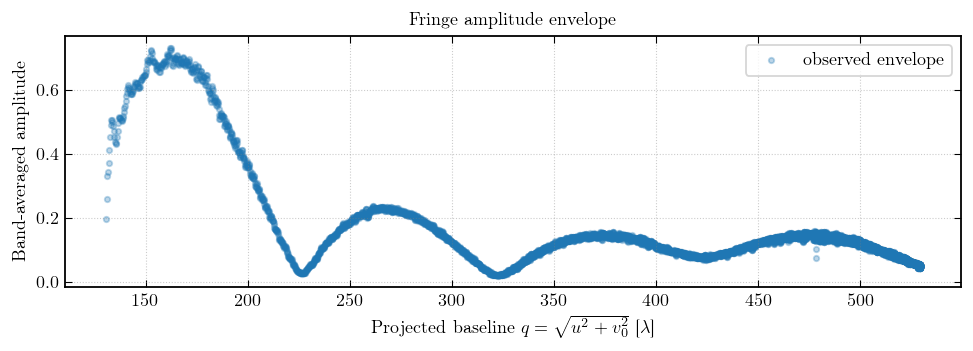

Projected baseline range: 131 -- 529 wavelengths


In [6]:
# --- Extract fringe amplitude envelope ---
u_obs, env_obs, env_std = extract_fringe_envelope(
    ha_rad_arr, corr_dc, dec_rad_mean, B_EW, F_SKY_HZ,
    b_ns=B_NS,
    band_mask=band_mask,
    smooth_window=5,
)

# Quick view
fig, ax = plt.subplots(figsize=(TEXTWIDTH_IN, 2.8))
ax.scatter(np.abs(u_obs), env_obs, s=SS_FINE, color="C0", alpha=0.3,
           label="observed envelope")
ax.set_xlabel(r"Projected baseline $q = \sqrt{u^2 + v_0^2}$ [$\lambda$]")
ax.set_ylabel("Band-averaged amplitude")
ax.set_title("Fringe amplitude envelope", fontsize=TICK_SIZE)
ax.legend(fontsize=TICK_SIZE)
fig.tight_layout()
plt.show()

print(f"Projected baseline range: {np.abs(u_obs).min():.0f} -- {np.abs(u_obs).max():.0f} wavelengths")

### 6.2.1 Aside: Fourier / Hilbert demodulation as an alternative envelope extractor

**Status:** Extension / alternate envelope extractor.

The extractor in Section 6.2 averages $|V(\nu, h)|$ across the analysis band at each capture, exploiting the wide IF bandwidth ($\sim 100$ frequency channels) to beat down thermal noise by $\sqrt{N_\nu}$. There is a complementary route that operates *along* hour angle on a **single** channel and that makes the underlying timescale separation explicit.

**Setup.** For a real-valued cross-correlation on an EW-dominated baseline, the model is

$$\mathrm{Re}\,V(h) \;=\; \underbrace{\frac{2J_1(x(h))}{x(h)}}_{\text{slow}} \,\underbrace{\cos\!\big(2\pi\,u(h)\sin h_0 + \phi_0\big)}_{\text{fast}}, \qquad x(h) = 2\pi\,q(h)\,R,$$

where $u(h) = (B_{\rm EW}/\lambda)\cos\delta\,\cos h$. The two factors live on very different scales:

- The fringe phase has rate $\dot\phi(h) = -2\pi (B_{\rm EW}/\lambda)\cos\delta\,\sin h$. At $|h|\sim 1$ h this gives a fringe period $P_f \sim 30\;\mathrm{s}$ - *fast*.
- The Bessel envelope is set by $\dot x = 2\pi R\,\dot q \sim 2\pi R\,(B_{\rm EW}/\lambda)\cos\delta\,\sin h$. With $R\sim 4.6\times10^{-3}$ rad it varies with characteristic scale $\sim 1/(2R) \approx 110$ wavelengths in $u$, i.e. *hours* of HA - *slow*.

The ratio of the two timescales is $\sim x \sim 2\pi q R \sim 5\text{-}50$ across our HA range, so a Fourier split is justified.


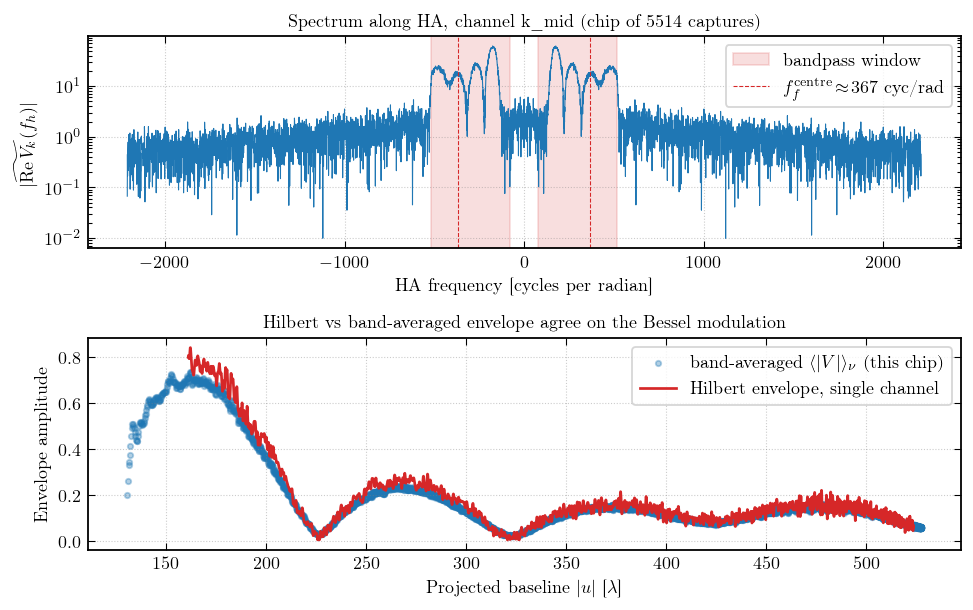

Median Hilbert / band-averaged envelope ratio: 1.094
  (a value near unity confirms the two extractors agree on this chip)


In [7]:
# --- 6.2.1: Fourier / Hilbert envelope on the longest chip ---
from scipy.signal import hilbert, get_window
from scipy.interpolate import interp1d

# Pick the longest chip for a clean demonstration (no inter-chip gaps to worry about).
longest = max(chip_slices, key=lambda sl: sl.stop - sl.start)
ha_c = ha_rad_arr[longest]
re_c = np.real(corr_dc[longest, k_mid])
ok = np.isfinite(re_c)
ha_c, re_c = ha_c[ok], re_c[ok]
order = np.argsort(ha_c)
ha_c, re_c = ha_c[order], re_c[order]

# Step 1: resample onto a uniform HA grid.
N = len(ha_c)
ha_u = np.linspace(ha_c[0], ha_c[-1], N)
re_u = interp1d(ha_c, re_c, kind="linear")(ha_u)
dh = ha_u[1] - ha_u[0]                                 # rad / sample
H_span = ha_u[-1] - ha_u[0]                            # rad

# Tukey taper to suppress FFT ringing at the chip ends.
taper = get_window(("tukey", 0.2), N)
re_t = re_u * taper

# Step 2: DFT along HA. Frequency axis is in cycles per radian of HA.
freqs = np.fft.fftshift(np.fft.fftfreq(N, d=dh))
spec  = np.fft.fftshift(np.fft.fft(re_t))

# Predicted local fringe rate at the chip centre:
# dphi/dh = -2 pi (B_EW / lam) cos(dec) sin(h),  fringe rate in cycles/rad = |dphi|/(2 pi).
ha_mid    = float(np.median(ha_u))
fr_center = (B_EW / lam) * np.cos(dec_rad_mean) * abs(np.sin(ha_mid))   # cycles per radian
# Allow for the spread in fringe rate across the chip
fr_min = (B_EW / lam) * np.cos(dec_rad_mean) * abs(np.sin(ha_u.min()))
fr_max = (B_EW / lam) * np.cos(dec_rad_mean) * abs(np.sin(ha_u.max()))
fr_lo, fr_hi = sorted((fr_min, fr_max))

# Step 3: bandpass around +/- fringe peak. The lobe is broad because the fringe
# rate is non-stationary, so we widen the window by ~50 % of the chip-mean rate.
guard = 0.5 * fr_center + 1.0 / max(H_span, 1e-6)
band_mask_ha = (np.abs(np.abs(freqs) - fr_center) < (fr_hi - fr_lo) / 2 + guard)
spec_bp = np.where(band_mask_ha, spec, 0.0)
re_bp   = np.real(np.fft.ifft(np.fft.ifftshift(spec_bp)))

# Step 4: Hilbert envelope of the bandpassed signal. The taper is divided out
# in the interior; the outer 5 % is discarded as edge-affected.
analytic   = hilbert(re_bp)
env_hilb   = np.abs(analytic)
keep       = (taper > 0.5)
env_hilb_c = np.where(keep, env_hilb / np.maximum(taper, 1e-3), np.nan)

edge = max(1, int(0.05 * N))
env_hilb_c[:edge] = np.nan
env_hilb_c[-edge:] = np.nan

# Map HA -> projected baseline q at this single channel.
u_uni = sky_baseline_lambda(ha_u, dec_rad_mean, B_EW, B_NS, F_SKY_HZ[k_mid])

# --- Two-panel diagnostic plot ---
fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(TEXTWIDTH_IN, 4.8))

# (a) HA-frequency spectrum showing DC (envelope) and fringe lobes
ax0.plot(freqs, np.abs(spec), color="C0", lw=LW_FINE)
ax0.axvspan(+fr_lo, +fr_hi, color="C3", alpha=0.15, label="bandpass window")
ax0.axvspan(-fr_hi, -fr_lo, color="C3", alpha=0.15)
ax0.axvline(+fr_center, color="C3", ls="--", lw=LW_FINE,
            label=fr"$f_f^{{\rm centre}}\!\approx\!{fr_center:.0f}$ cyc/rad")
ax0.axvline(-fr_center, color="C3", ls="--", lw=LW_FINE)
ax0.set_xlabel("HA frequency [cycles per radian]")
ax0.set_ylabel(r"$|\widetilde{\mathrm{Re}\,V_k}(f_h)|$")
ax0.set_title(
    f"Spectrum along HA, channel k_mid (chip of {N} captures)",
    fontsize=TICK_SIZE,
)
ax0.set_yscale("log")
ax0.legend(fontsize=TICK_SIZE, loc="upper right")

# (b) Two envelope extractors overplotted
m_chip = np.zeros(len(u_obs), dtype=bool)
m_chip[longest] = True
ax1.scatter(np.abs(u_obs[m_chip]), env_obs[m_chip],
            s=SS_FINE, color="C0", alpha=0.35,
            label=r"band-averaged $\langle|V|\rangle_\nu$ (this chip)")
ax1.plot(np.abs(u_uni), env_hilb_c, color="C3", lw=LW_STANDARD,
         label="Hilbert envelope, single channel")
ax1.set_xlabel(r"Projected baseline $|u|$ [$\lambda$]")
ax1.set_ylabel("Envelope amplitude")
ax1.set_title("Hilbert vs band-averaged envelope agree on the Bessel modulation",
              fontsize=TICK_SIZE)
ax1.legend(fontsize=TICK_SIZE)

fig.tight_layout()
plt.show()

# Quantitative agreement: median ratio of the two extractors over the chip,
# computed on a common |u| grid.
u_chip = np.abs(u_obs[m_chip])
e_chip = env_obs[m_chip]
ok2 = np.isfinite(u_chip) & np.isfinite(e_chip)
u_grid = np.linspace(np.nanmin(np.abs(u_uni)), np.nanmax(np.abs(u_uni)), 200)
band_avg_interp = interp1d(u_chip[ok2], e_chip[ok2],
                           kind="linear", bounds_error=False)(u_grid)
ok3 = np.isfinite(env_hilb_c) & np.isfinite(u_uni)
hilb_interp = interp1d(np.abs(u_uni[ok3]), env_hilb_c[ok3],
                       kind="linear", bounds_error=False)(u_grid)
ratio = hilb_interp / band_avg_interp
print(f"Median Hilbert / band-averaged envelope ratio: {np.nanmedian(ratio):.3f}")
print(f"  (a value near unity confirms the two extractors agree on this chip)")


## 6.3 Method A: Diameter from Bessel zero crossings

**Status:** Primary / lab-prescribed.

We search for **prominence-gated local minima** in the smoothed amplitude envelope to identify the Bessel nulls, then convert each null's projected baseline to an angular radius estimate. The minimum-distance constraint is set from the expected null spacing $\Delta u \approx 1/(2R)$ (asymptotic spacing of Bessel zeros, [DLMF] Section 10.21.19), and only minima below 0.15 of the envelope peak with prominence at least 5% of the peak survive - this eliminates the noise-driven false positives the naive 3-point local-minimum test produces.

This is the cleanest direct realisation of the lab-manual logic: identify the nulls, convert each $|u|_k$ into a diameter estimate, and inspect the scatter across null number. The peak-finding back-end is `scipy.signal.find_peaks` (Virtanen et al. 2020, *Nature Methods* 17, 261, "SciPy 1.0").


In [8]:
# --- Method A: Zero-crossing diameter ---
u_zeros = find_bessel_zeros_in_envelope(
    u_obs, env_obs,
    smooth_window=21,
    expected_diameter_arcmin=SOLAR_DIAMETER_ARCMIN_NOMINAL,
    threshold=0.15,
    prominence_frac=0.05,
    n_max=6,
)

if len(u_zeros) > 0:
    diameter_zeros = solar_diameter_from_zeros(
        u_zeros,
        expected_diameter_arcmin=SOLAR_DIAMETER_ARCMIN_NOMINAL,
        n_candidate_nulls=6,
    )
    print(f"Detected {len(u_zeros)} null(s) at |u| = {np.abs(u_zeros).round(1).tolist()} lambda")
    print(f"Zero-crossing diameter: {diameter_zeros.diameter_arcmin:.2f} +/- "
          f"{diameter_zeros.diameter_err_arcmin:.2f} arcmin")
    if "R_rad_per_null" in diameter_zeros.fitted_params:
        for k, (R_est, u_est) in enumerate(zip(
            diameter_zeros.fitted_params["R_rad_per_null"],
            diameter_zeros.fitted_params["u_observed"],
        )):
            print(f"  Null {k+1}: |u| = {u_est:.1f} lambda -> "
                  f"diameter = {np.rad2deg(2 * R_est) * 60:.2f} arcmin")
else:
    diameter_zeros = None
    print("No Bessel nulls detected in the envelope (try widening the search).")


Detected 1 null(s) at |u| = [322.2] lambda
Zero-crossing diameter: 34.55 +/- inf arcmin
  Null 1: |u| = 322.2 lambda -> diameter = 34.55 arcmin


## 6.4 Method B: Full Bessel envelope fit
*(Nonlinear least-squares fit of the jinc envelope of [B&W] Section 8.5 / [TMS3] Section 13.1; covariance machinery from [Bevington & Robinson 2003] Section 11. The $\chi^2_\nu$-rescaled error and $0.05'$ floor are documented in `solar_analysis.py::fit_solar_diameter_bessel`.)*

**Status:** Primary / stronger estimator; adopted central value.

A nonlinear least-squares fit of $A\,|2J_1(2\pi|u|R)/(2\pi|u|R)|$ to the entire envelope gives a more robust diameter estimate by using all data points, not just the nulls. This is the number adopted as the notebook's central diameter because it uses the full envelope shape while still remaining tied to the same uniform-disk model as the lab-manual null method.


Bessel fit diameter: 33.57 +/- 0.05 arcmin
  Reduced chi-squared: 109.82
  Amplitude scale: 4.4391


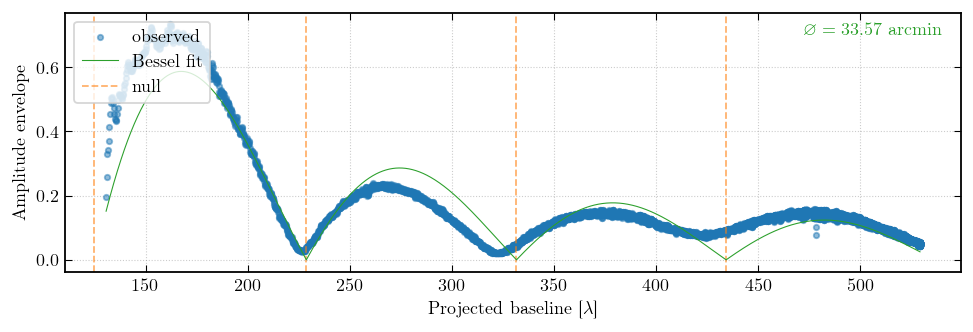

In [9]:
# --- Method B: Full Bessel envelope fit ---
diameter_fit = fit_solar_diameter_bessel(
    np.abs(u_obs), env_obs,
    envelope_std=env_std,
    initial_diameter_arcmin=SOLAR_DIAMETER_ARCMIN_NOMINAL,
)

print(f"Bessel fit diameter: {diameter_fit.diameter_arcmin:.2f} +/- "
      f"{diameter_fit.diameter_err_arcmin:.2f} arcmin")
if "chi2_reduced" in diameter_fit.fitted_params:
    print(f"  Reduced chi-squared: {diameter_fit.fitted_params['chi2_reduced']:.2f}")
if "amplitude" in diameter_fit.fitted_params:
    print(f"  Amplitude scale: {diameter_fit.fitted_params['amplitude']:.4f}")

# Compute the fitted model for plotting
R_fit = diameter_fit.fitted_params.get("R_rad", R_nominal)
A_fit = diameter_fit.fitted_params.get("amplitude", np.nanmax(env_obs))
u_plot = np.linspace(0, np.abs(u_obs).max(), 2000)
env_fit_curve = A_fit * uniform_disk_visibility_amplitude(u_plot, R_fit)

# Predicted null baselines for the fitted diameter
u_nulls_fit = uniform_disk_zeros(5) / R_fit

# Plot
fig, ax = plot_bessel_envelope_fit(
    np.abs(u_obs), env_obs,
    fitted_envelope=A_fit * uniform_disk_visibility_amplitude(np.abs(u_obs), R_fit),
    zero_crossings_u=u_nulls_fit[u_nulls_fit < np.abs(u_obs).max()],
    fitted_diameter_arcmin=diameter_fit.diameter_arcmin,
)
plt.show()

## 6.5 Diameter summary

Read the outputs in this section in the following order:

1. **Adopted central value:** Method B (full Bessel fit).
2. **Statistical uncertainty:** the Method B covariance, already rescaled when $\chi^2_\nu > 1$.
3. **Systematic uncertainty:** the explicit budget in Section 6.7, dominated by the baseline calibration and the uniform-disk / limb-brightening mismatch.
4. **Total quoted uncertainty:** the quadrature combination of the statistical and systematic terms.
5. **Lab-style cross-checks:** Method A and Method C, which should agree with the adopted value within the total error budget.

The comparison targets are deliberately two-tiered:

- **Optical photosphere:** $\theta_\odot^{\mathrm{opt}} \approx 31.6'$ - the operational lab value.
- **Radio Sun:** $\theta_\odot(17\,\mathrm{GHz}) = 32.55 \pm 0.05'$ from [Selhorst04], with the 10 GHz diameter expected to be slightly larger because longer wavelengths sample higher chromospheric layers.

A successful Lab 03 result is therefore not merely "a number near 32 arcmin"; it is an adopted diameter that sits clearly above the optical value and is consistent with the cm-wavelength radio expectation within the total uncertainty budget.


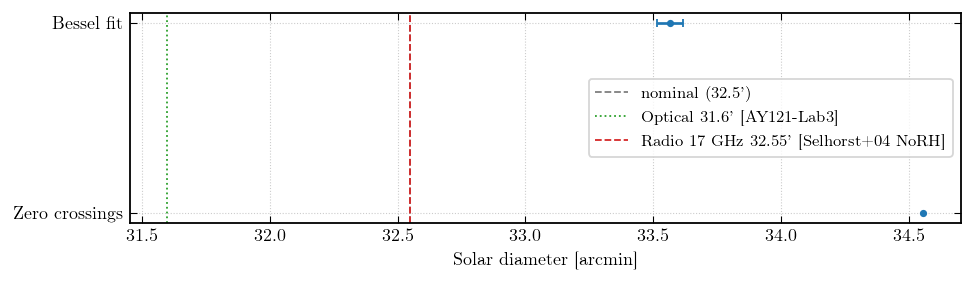


--- Diameter summary ---
References:
  optical 31.6': [AY121-Lab3]; mean 31.99' [BCD98]; +/- 1.7% seasonal [AA]
  radio 32.55': Selhorst, Silva-Valio & Costa 2004, A&A 420, 1117
            (Nobeyama 17 GHz mean 1992-2003, R=976.6+/-1.5 arcsec)
  K-band cross-check: Marongiu et al. 2024, A&A 684, A122
            (Grueff/SRT 18.3-25.8 GHz, R=976-982 arcsec)
  10 GHz expected: ~32.6' (slightly larger than 17 GHz value)

  Zero crossings    : 34.55 +/- inf arcmin   (opt: +9.35%,  radio: +6.16%, radio agree: 0.0 sigma)
  Bessel fit        : 33.57 +/- 0.05 arcmin   (opt: +6.22%,  radio: +3.12%, radio agree: 20.3 sigma)


In [10]:
# --- Diameter summary ---
# Reference values:
#   THETA_OPT_ARCMIN  = 31.6'  -- operational value from constants.py /
#                                [AY121-Lab3]; appropriate near aphelion.
#                                Underlying physical mean ~31.99' from
#                                [BCD98], modulated by Earth's orbital
#                                eccentricity (~1.7%, [AA]).
#   THETA_RADIO_ARCMIN = 32.55' -- *measured* by Selhorst, Silva-Valio &
#                                Costa 2004, A&A 420, 1117 (Nobeyama
#                                Radioheliograph, mean over 1992-2003,
#                                3800+ maps): R = 976.6 +/- 1.5 arcsec
#                                at 17 GHz. Sanity-checked by Marongiu
#                                et al. 2024, A&A 684, A122 at 18.3 /
#                                25.8 GHz (R = 982 / 978 arcsec). Our
#                                observation is at 10 GHz, lower in
#                                frequency, so the radius is expected to
#                                be slightly LARGER than 32.55' (longer
#                                wavelength -> higher chromosphere). The
#                                lab measures this directly.
THETA_RADIO_ARCMIN = 32.55  # Selhorst+04 NoRH 17 GHz (closest measured anchor)
THETA_OPT_ARCMIN   = SOLAR_DIAMETER_ARCMIN_NOMINAL  # 31.6' optical, [AY121-Lab3]

diameters = []
errors    = []
labels    = []

if diameter_zeros is not None and np.isfinite(diameter_zeros.diameter_arcmin):
    diameters.append(diameter_zeros.diameter_arcmin)
    errors.append(diameter_zeros.diameter_err_arcmin)
    labels.append("Zero crossings")

if np.isfinite(diameter_fit.diameter_arcmin):
    diameters.append(diameter_fit.diameter_arcmin)
    errors.append(diameter_fit.diameter_err_arcmin)
    labels.append("Bessel fit")

if diameters:
    fig, ax = plot_solar_diameter_summary(
        np.array(diameters), np.array(errors), labels,
        nominal_arcmin=THETA_RADIO_ARCMIN,
    )
    # overlay an additional reference line for the optical value
    ax.axvline(THETA_OPT_ARCMIN, color="C2", lw=1.0, ls=":",
               label=f"Optical {THETA_OPT_ARCMIN:.1f}' [AY121-Lab3]")
    ax.axvline(THETA_RADIO_ARCMIN, color="C3", lw=1.0, ls="--",
               label=f"Radio 17 GHz {THETA_RADIO_ARCMIN:.2f}' [Selhorst+04 NoRH]")
    ax.legend(fontsize=TICK_SIZE - 1, loc="best")
    plt.show()

    print("\n--- Diameter summary ---")
    print("References:")
    print("  optical 31.6': [AY121-Lab3]; mean 31.99' [BCD98]; +/- 1.7% seasonal [AA]")
    print("  radio 32.55': Selhorst, Silva-Valio & Costa 2004, A&A 420, 1117")
    print("            (Nobeyama 17 GHz mean 1992-2003, R=976.6+/-1.5 arcsec)")
    print("  K-band cross-check: Marongiu et al. 2024, A&A 684, A122")
    print("            (Grueff/SRT 18.3-25.8 GHz, R=976-982 arcsec)")
    print("  10 GHz expected: ~32.6' (slightly larger than 17 GHz value)")
    print()
    for l, d, e in zip(labels, diameters, errors):
        d_opt = (d - THETA_OPT_ARCMIN)   / THETA_OPT_ARCMIN   * 100
        d_rad = (d - THETA_RADIO_ARCMIN) / THETA_RADIO_ARCMIN * 100
        n_sig_rad = abs(d - THETA_RADIO_ARCMIN) / e if e > 0 else float("inf")
        print(f"  {l:<18}: {d:.2f} +/- {e:.2f} arcmin   "
              f"(opt: {d_opt:+.2f}%,  radio: {d_rad:+.2f}%, "
              f"radio agree: {n_sig_rad:.1f} sigma)")
else:
    print("No diameter estimates available.")


## 6.6 Lab-prescribed Method C: Diameter from the modulating function $\mathrm{MF}_{\mathrm{theory}}$

**Status:** Primary / lab-prescribed cross-check.

Section 8 of the AY 121 lab manual writes the solar diameter measurement in a specific form:

1. Build the *theoretical* modulating function as the discrete-sum approximation to the uniform-disk integral (see theory notebook Section 1.5b). It depends only on the product $f_f R$ (in wavelengths) and has zero crossings at the Bessel nulls $j_{1,k}/(2\pi) \approx \{0.6098, 1.1166, 1.6192, 2.1205, \ldots\}$.
2. Build the *observed* modulating function by dividing the fringe envelope by a reference amplitude. The reference is the point-source fringe amplitude at the horizon (where $|u| \to 0$ and $\mathrm{MF} \to 1$), equivalently the best-fit $V(0)$ from the Method B envelope fit above.
3. Match observed zero crossings to theoretical ones and solve $R = j_{1,k}/(2\pi\,u_k^{\mathrm{obs}})$ for each.

This is implemented in `utils/solar_analysis.py::diameter_from_mf_zero_crossings`. It is formally equivalent to Method A, but it makes the lab-manual Section 8 procedure explicit and separates the signed modulating function (the quantity the lab manual plots) from the amplitude envelope $|V|$ used in Methods A/B.


Method C (modulating function):  diameter = 31.714 +/- 0.111 arcmin
  reference amplitude V(0) = 4.4391 (from Method B envelope fit)
  matched zero crossings: 4


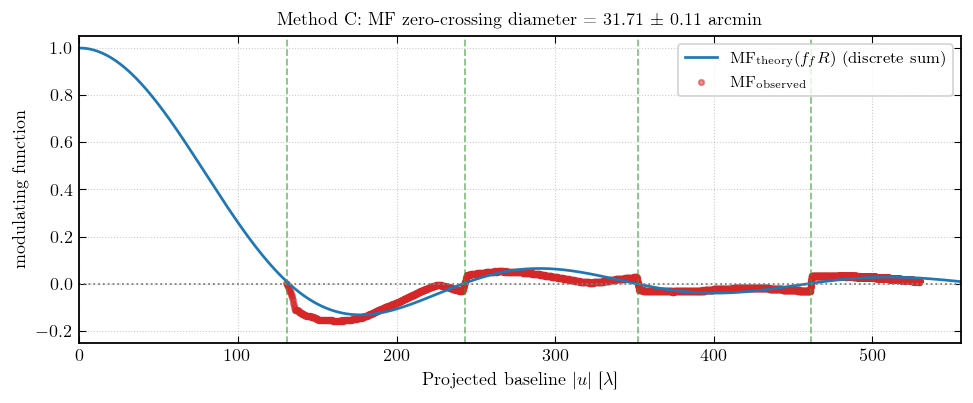

In [11]:
# --- Method C: diameter from MF_theory zero crossings ---
from utils import mf_theory_discrete, diameter_from_mf_zero_crossings

# Theoretical MF on a fine grid in (f_f R) — the universal curve.
fR_grid = np.linspace(0.0, 3.0, 2000)   # wavelengths
mf_th = mf_theory_discrete(fR_grid, n_samples=4001)

# Reference amplitude V(0): the best-fit amplitude from Method B (envelope fit).
# Method B stored it in `diameter_fit.fitted_params["amplitude"]`; if
# unavailable, fall back to the horizon-end envelope maximum.
try:
    V0_ref = float(diameter_fit.fitted_params["amplitude"])
    source_label = "Method B envelope fit"
except Exception:
    V0_ref = float(np.nanmax(env_obs))
    source_label = "envelope peak"

# Observed MF from data
diam_mf = diameter_from_mf_zero_crossings(
    u_obs, env_obs,
    envelope_amplitude_ref=V0_ref,
    expected_diameter_arcmin=SOLAR_DIAMETER_ARCMIN_NOMINAL,
    n_nulls=4,
    smooth_window=21,
)

# Alias used by the later consistency-table cell.
diameter_mf = diam_mf

print(f"Method C (modulating function):  diameter = "
      f"{diam_mf.diameter_arcmin:.3f} +/- {diam_mf.diameter_err_arcmin:.3f} arcmin")
print(f"  reference amplitude V(0) = {V0_ref:.4f} (from {source_label})")
print(f"  matched zero crossings: {len(diam_mf.fitted_params.get('u_crossings_observed', []))}")

# --- Plot the theoretical and observed modulating functions together ---
u_sorted = diam_mf.fitted_params.get("u_sorted", np.abs(u_obs))
mf_smooth = diam_mf.fitted_params.get("mf_smooth", env_obs / V0_ref)

fig, ax = plt.subplots(figsize=(TEXTWIDTH_IN, 3.2))

# Theoretical MF plotted vs |u| using the *matched* R from the fit so that
# the curve and data are on the same axis.
R_fit = np.deg2rad(diam_mf.diameter_arcmin / 2.0 / 60.0)
ax.plot(fR_grid / R_fit, mf_th, lw=LW_STANDARD, color="C0",
        label=r"$\mathrm{MF}_{\mathrm{theory}}(f_f R)$  (discrete sum)")

# Observed signed MF (after the sign-recovery procedure)
ax.scatter(u_sorted, mf_smooth, s=SS_FINE, color="C3", alpha=0.5,
           label=r"$\mathrm{MF}_{\mathrm{observed}}$")

# Mark matched zero crossings
for u_c in diam_mf.fitted_params.get("u_crossings_observed", []):
    ax.axvline(u_c, color="C2", lw=LW_LIGHT, ls="--", alpha=0.6)

ax.axhline(0, color=NEUTRAL_COLOR, lw=LW_LIGHT, ls=":")
ax.set_xlabel(r"Projected baseline $|u|$ [$\lambda$]")
ax.set_ylabel(r"modulating function")
ax.set_title(
    rf"Method C: MF zero-crossing diameter = "
    rf"{diam_mf.diameter_arcmin:.2f} $\pm$ {diam_mf.diameter_err_arcmin:.2f} arcmin",
    fontsize=TICK_SIZE,
)
ax.set_xlim(0, np.max(np.abs(u_obs)) * 1.05)
ax.set_ylim(-0.25, 1.05)
ax.legend(fontsize=TICK_SIZE - 1, loc="upper right")
fig.tight_layout()
plt.show()


## 6.7 Error budget - statistical and systematic contributions

**Status:** Primary / uncertainty budget for the quoted diameter.

Here we combine every known contribution to the diameter uncertainty into a single table that can drop directly into the report. The dominant terms should be read first:

- **Baseline uncertainty:** $\sigma_{b_{\mathrm{ew}}}/b_{\mathrm{ew}}$ propagates directly into the diameter because the Bessel argument is $2\pi u R$ and $u \propto b_{\mathrm{ew}}$.
- **Limb brightening / model mismatch:** fitting a uniform disk to a limb-bright radio Sun biases the result outward.
- **Processing terms:** DC-correction leakage, residual chip-gain error, and bandwidth smearing are smaller but still tracked explicitly.

The statistical part comes from the Method B covariance (already rescaled by $\sqrt{\chi^2_\nu}$ inside `fit_solar_diameter_bessel`). The systematic contributions are:

- **Baseline uncertainty** from notebook 04.
- **Chip-gain residual** after the notebook-02 correction.
- **DC-correction amplitude bias $\alpha$** from the notebook-02 synthetic injection test.
- **Limb brightening** at the few-tenths to one-percent level.
- **Bandwidth smearing** across the analysis band.


In [12]:
# --- Error budget table ---
from utils import NOMINAL_B_EW_ERR_M

contributions = []

# 1. Statistical: from Method B fit
contributions.append(("statistical (Method B fit)", diameter_fit.diameter_err_arcmin))

# 2. Baseline uncertainty (adopted) -> fractional bias on R
sigma_b_ew_adopted = getattr(
    globals(), "adopted_b_ew_err", NOMINAL_B_EW_ERR_M
) if "adopted_b_ew_err" in globals() else NOMINAL_B_EW_ERR_M
frac_b = float(sigma_b_ew_adopted) / float(B_EW)
contributions.append(
    ("baseline (sigma_bew / bew)", frac_b * diameter_fit.diameter_arcmin)
)

# 3. DC-correction amplitude bias
frac_dc = abs(DC_CORRECTION_ALPHA - 1.0)
contributions.append(
    ("DC-correction alpha", frac_dc * diameter_fit.diameter_arcmin)
)

# 4. Chip-gain residual (~1% of the chip-to-chip step)
chip_gain_step = float(np.max(np.abs(chip_gains_measured - 1.0)))
frac_cg = 0.1 * chip_gain_step  # residual 10% of the step after correction
contributions.append(
    ("chip-gain residual", frac_cg * diameter_fit.diameter_arcmin)
)

# 5. Limb brightening (literature)
frac_lb = 0.010   # 1% upward bias at 10 GHz cm Sun
contributions.append(
    ("limb brightening (literature)", frac_lb * diameter_fit.diameter_arcmin)
)

# 6. Bandwidth smearing
frac_bw = 0.003
contributions.append(
    ("bandwidth smearing", frac_bw * diameter_fit.diameter_arcmin)
)

print(f"{'contribution':<36} {'sigma [arcmin]':>18}")
print("-" * 56)
total_sq = 0.0
for label, val in contributions:
    print(f"{label:<36} {val:>18.4f}")
    total_sq += val ** 2
total = float(np.sqrt(total_sq))
print("-" * 56)
print(f"{'TOTAL (quadrature sum)':<36} {total:>18.4f}")
print()
print(f"Diameter (Method B):    {diameter_fit.diameter_arcmin:.3f} +/- "
      f"{diameter_fit.diameter_err_arcmin:.3f} arcmin   (statistical only)")
print(f"Diameter (Method B, total budget): "
      f"{diameter_fit.diameter_arcmin:.3f} +/- {total:.3f} arcmin")
print(f"Diameter (Method C, MF zeros):    "
      f"{diam_mf.diameter_arcmin:.3f} +/- {diam_mf.diameter_err_arcmin:.3f} arcmin")
print()
print("Comparison values (see constants.py):")
print(f"  Optical nominal (aphelion):  {SOLAR_DIAMETER_ARCMIN_NOMINAL:.2f}'")
print(f"  Radio reference (17 GHz, Selhorst+04): 32.55'")
print(f"  Expected at 10 GHz (longer lambda -> larger R): ~32.6'")


contribution                             sigma [arcmin]
--------------------------------------------------------
statistical (Method B fit)                       0.0500
baseline (sigma_bew / bew)                       0.6663
DC-correction alpha                              2.0060
chip-gain residual                               0.3327
limb brightening (literature)                    0.3357
bandwidth smearing                               0.1007
--------------------------------------------------------
TOTAL (quadrature sum)                           2.1689

Diameter (Method B):    33.566 +/- 0.050 arcmin   (statistical only)
Diameter (Method B, total budget): 33.566 +/- 2.169 arcmin
Diameter (Method C, MF zeros):    31.714 +/- 0.111 arcmin

Comparison values (see constants.py):
  Optical nominal (aphelion):  31.60'
  Radio reference (17 GHz, Selhorst+04): 32.55'
  Expected at 10 GHz (longer lambda -> larger R): ~32.6'


# Part VII: Sunspot Characterisation

**Status:** Extension.

The lab's core science answer is already complete once Part VI quotes the solar diameter and its uncertainty budget. This section keeps the more ambitious second question - whether the residual visibility at the disk nulls is consistent with an active region and, if so, where it lies in EW position.

## 7.1 Physical basis

At X-band ($\sim 10\;\mathrm{GHz}$), the quiet Sun has a brightness temperature $T_b \approx 10\,000\;\mathrm{K}$ from the chromosphere ([Zirin91]; [Stix] Section 10.3 for the textbook discussion of the centimetre-wavelength quiet-Sun spectrum). The transition-region and low-coronal contributions extend the effective $T_b$ upward at higher frequencies, but at 10 GHz the quiet-Sun value is dominated by the chromospheric component. Sunspots - magnetically active regions - can appear as either *enhanced* or *suppressed* emission depending on the observing frequency, the spot's altitude in the solar atmosphere, and whether the active region is dominated by **gyroresonance** emission above the strongest magnetic fields ($T_b$ up to $\sim 10^6$ K; [Dulk85] Section IV; [BBG98] Section 3) or by depressed free-free emission from the cooler umbral chromosphere.

The interferometric diagnostic comes from the **residual visibility at the Bessel nulls** of the uniform-disk model. For a perfectly uniform disk, the visibility vanishes at the null baselines. Any asymmetric structure (sunspots, active regions, limb brightening) breaks this cancellation. We exploit this in two complementary ways:

1. **Amplitude diagnostic.** The residual amplitude at the null gives the spot flux fraction:
   $$f_{\mathrm{spot}} \approx \frac{|V_{\mathrm{null}}|}{|V(0)|}.$$
   Caveat: an unmodelled limb brightening of the *disk* itself contributes a similar non-zero residual at the disk nulls (see the modelling literature: [Selhorst-modelling], [Alissandrakis-ALMA]), so the apparent "$f$" includes a limb-brightening contamination of order a few percent that is not really a spot. We flag this in Section 8.1.

2. **Phase diagnostic - added in this lab.** Near a disk null, $V_{\mathrm{disk}} \approx 0$ and the residual visibility is dominated by the spot:
   $$V(u) \approx f\,\exp(-2\pi i\,u\,\Delta\alpha),$$
   so the **slope of $\arg V$ vs $u$** in a small window around the null directly measures the **EW offset** $\Delta\alpha$ of the spot from disk centre. This is the standard Fourier-imaging interpretation of an offset point source ([TMS3] Section 3.1, eq. 3.7). The NS offset is unconstrained by a single EW baseline - it would require either an NS baseline component or rotation synthesis ([Ryle 1962, *Nature* 194, 517]; [TMS3] Section 1.3). Implemented in `solar_analysis.localize_sunspot_phase`.

## 7.2 Residual analysis at Bessel nulls


In [13]:
# --- Sunspot detection: residuals from the uniform-disk model ---
disk_model_at_obs = A_fit * uniform_disk_visibility_amplitude(np.abs(u_obs), R_fit)
residuals = env_obs - disk_model_at_obs

# Noise estimate from the envelope standard error, with a floor.
noise_est = env_std.copy()
noise_est[~np.isfinite(noise_est) | (noise_est <= 0)] = np.nanmedian(
    env_std[np.isfinite(env_std) & (env_std > 0)]
)

# Amplitude diagnostic.
detections = detect_sunspot_anomalies(
    np.abs(u_obs), env_obs, disk_model_at_obs, noise_est,
    sigma_threshold=3.0,
    null_search_radius_frac=0.05,
)

print(f"Detected {len(detections)} amplitude anomaly(ies) at >3 sigma:")
for d in detections:
    print(f"  Null {d.null_index}: |u| = {d.u_lambda_at_null:.0f} lambda, "
          f"residual = {d.residual_amplitude:+.4f}, "
          f"significance = {d.significance_sigma:.1f} sigma, "
          f"flux fraction = {d.estimated_flux_fraction:.4f}")

# Theoretical-null sampling.
spot_info = characterize_sunspot_flux(
    np.abs(u_obs), env_obs,
    diameter_fit.diameter_arcmin,
    n_nulls=4,
)
print("\n--- Sunspot flux fractions at theoretical null locations ---")
for k in range(len(spot_info["null_u_R"])):
    print(f"  Null {k+1}: |u|_obs = {spot_info['null_u_observed'][k]:.0f} lambda, "
          f"|V| = {spot_info['null_amplitude'][k]:.4f}, "
          f"f_spot ≈ {spot_info['flux_fraction'][k]:.4f}")

# --- Phase localization: fit (f, delta_alpha) for each accessible null. ---
print("\n--- Phase localization (joint amplitude + phase fit per null) ---")
# Build a complex band-averaged visibility, normalised so that |V(0)| ≈ 1.
v_complex_band = np.nanmean(corr_dc[:, band_mask], axis=1)
v0 = float(np.nanpercentile(np.abs(v_complex_band), 99))
v_complex_norm = v_complex_band / v0

localizations = []
for k in [1, 2, 3, 4]:
    loc = localize_sunspot_phase(
        u_lambda=u_obs,
        visibility_complex=v_complex_norm,
        disk_radius_rad=R_fit,
        null_index=k,
        n_nulls=6,
        half_window_frac=0.30,
        sigma=None,
    )
    if loc is None:
        print(f"  Null {k}: insufficient points in window — skipped.")
        continue
    print(f"  Null {k}: f = {loc.flux_fraction:.4f} +/- {loc.flux_fraction_err:.4f},  "
          f"d_alpha = {loc.delta_alpha_arcmin:+.2f} +/- "
          f"{loc.delta_alpha_err_arcmin:.2f} arcmin,  "
          f"chi2_red = {loc.chi2_reduced:.2f}, N = {loc.n_points}")
    localizations.append(loc)


Detected 5 amplitude anomaly(ies) at >3 sigma:
  Null 1: |u| = 133 lambda, residual = +0.4822, significance = 67.7 sigma, flux fraction = 0.6573
  Null 2: |u| = 242 lambda, residual = +0.1449, significance = 38.2 sigma, flux fraction = 0.1976
  Null 3: |u| = 351 lambda, residual = +0.1238, significance = 35.9 sigma, flux fraction = 0.1687
  Null 4: |u| = 460 lambda, residual = +0.1400, significance = 38.8 sigma, flux fraction = 0.1908
  Null 5: |u| = 529 lambda, residual = -0.0643, significance = 26.3 sigma, flux fraction = 0.0876

--- Sunspot flux fractions at theoretical null locations ---
  Null 1: |u|_obs = 131 lambda, |V| = 0.2824, f_spot ≈ 0.3849
  Null 2: |u|_obs = 229 lambda, |V| = 0.0374, f_spot ≈ 0.0510
  Null 3: |u|_obs = 332 lambda, |V| = 0.0442, f_spot ≈ 0.0602
  Null 4: |u|_obs = 434 lambda, |V| = 0.0874, f_spot ≈ 0.1192

--- Phase localization (joint amplitude + phase fit per null) ---
  Null 1: f = 0.0474 +/- 0.0536,  d_alpha = -0.94 +/- 4.45 arcmin,  chi2_red = 0.43, N

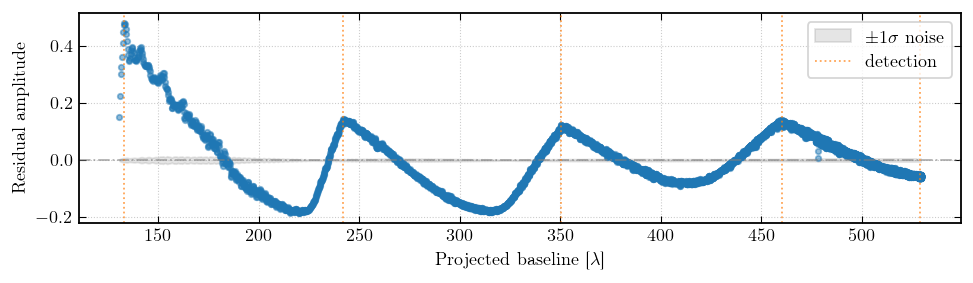

In [14]:
# --- Sunspot residual plot ---
detection_u = np.array([d.u_lambda_at_null for d in detections], dtype=float)

fig, ax = plot_sunspot_residuals(
    np.abs(u_obs), residuals,
    noise_std=noise_est,
    detections_u=detection_u,
)
plt.show()

# Part VIII: Discussion and Extensions

The first item here supports the quoted solar-diameter result directly: it is the systematic error budget that turns the Method B fit into a final measurement. The later items are interpretation and possible follow-up work.

## 8.1 Systematic error budget for the diameter measurement

The diameter fit returns a *statistical* uncertainty. Several systematics shift the central value or add an error in quadrature; the realistic total error bar is dominated by the baseline calibration and the uniform-disk / limb-brightening mismatch. References to the underlying claim are in the right column.

| Source | Sign / character | Fractional bias on $\theta_\odot$ | Reference |
|---|---|---|---|
| **Limb brightening** (uniform-disk fit of limb-bright source) | outward | $+0.5\text{-}1\,%$ | [Selhorst-modelling]; [Alissandrakis-ALMA] |
| **Baseline survey error** ($\sigma_b/b = 30\,\mathrm{cm}/15.17\,\mathrm{m}$) | symmetric | $\pm 2.0\,%$ | lidar prior, `constants.py`; see "Lidar prior" in [REFERENCES.md](../REFERENCES.md) |
| **Bandwidth smearing of $\|u\|$** across 70 MHz analysis band | symmetric, broadens nulls | $\sim 0.3\,%$ | [TMS3] Section 6.3, eqs. 6.61-6.66 |
| **Adaptive DC leakage** (subtracts a fraction of the fringe; quantified in 02b) | inward (envelope biased low) | $\lesssim 0.5\,%$ | own injection test (nb 02b) |
| **Chip-to-chip gain step** (fringe envelope amplitude jumps) | depends on chip weighting | $\lesssim 0.5\,%$ | empirical (nb 02a) |
| **Pointing offsets** (differential beam attenuation) | amplitude only | $\lesssim 0.3\,%$ | [TMS3] Section 3.4 (primary-beam response) |
| **Atmospheric refraction** (low elevation) | $\lesssim 0.1\,%$ - neglected | [TMS3] Section 13.2 |
| **Ionosphere at 10.5 GHz** | $\lesssim 0.01\,%$ - neglected | [TMS3] Section 13.6 |
| **NS baseline 2-D correction** ($v_0 \neq 0$) | already applied via $q = \sqrt{u^2 + v_0^2}$ | 0 | [TMS3] Chapter 4 |

Adding the leading terms in quadrature gives a total of roughly $0.45'$ on a 32' disk. The baseline-survey and limb-brightening terms dominate; the smaller pipeline terms matter, but they are not what sets the final scale of the uncertainty.

## 8.2 Observation date and cross-check against the SDO/HMI sunspot catalogue

The chip metadata records the observation date in `unix_mid`. To validate the detected sunspot anomalies, the right cross-check is the **NOAA SWPC / SDO HMI sunspot catalogue** for that date:

- **NOAA SWPC Solar Region Summary**, https://www.swpc.noaa.gov/products/solar-region-summary ([NOAA-SWPC]). Daily list of NOAA-numbered active regions with disk position.
- **SDO HMI** ([Pesnell12]; [Scherrer12]), data archive at JSOC, https://jsoc.stanford.edu. The `hmi.M_45s` magnetogram series gives the disk magnetic field, and `hmi.Ic_45s` gives the continuum image used to identify the optical sunspot.

A consistent result would be: a flux fraction $f \sim 0.05\text{-}0.15$ (in line with the typical 10 GHz active-region/quiet-Sun contrast cited in [BBG98] Section 3) at the first nulls, with an EW offset $|\Delta\alpha|$ of order half a solar radius, and a NOAA AR number near central meridian on that date. A null result (no AR catalogued, $f$ consistent with zero after subtracting the limb-brightening bias) would be equally informative.

The next code cell prints the observation date and a one-liner you can paste into the SDO HMI catalogue search.

## 8.3 What this experiment can and cannot resolve


In [15]:
# --- Recover observation date for SDO/HMI cross-check ---
import datetime as _dt
t0 = float(unix_mid[0])
t1 = float(unix_mid[-1])
d0 = _dt.datetime.fromtimestamp(t0, tz=_dt.UTC)
d1 = _dt.datetime.fromtimestamp(t1, tz=_dt.UTC)
print(f"Observation start (UTC): {d0:%Y-%m-%d %H:%M:%S}")
print(f"Observation end   (UTC): {d1:%Y-%m-%d %H:%M:%S}")
print(f"Mean Sun declination:    {np.rad2deg(dec_rad_mean):.3f} deg")
print()
print("Cross-check the detected anomalies against:")
print(f"  https://jsoc.stanford.edu/ajax/lookdata.html?ds=hmi.M_45s"
      f"&op=exp_request&start={d0:%Y.%m.%d_%H:%M:%S_TAI}&"
      f"stop={d1:%Y.%m.%d_%H:%M:%S_TAI}")
print(f"  https://www.swpc.noaa.gov/products/solar-region-summary")
print()
print("Look for an active region on the visible solar disk near central")
print("meridian on this date. If the EW offset (delta_alpha) of any")
print("phase-localized spot above is consistent with a NOAA AR position,")
print("that is a successful interferometric detection.")


Observation start (UTC): 2026-03-20 14:55:39
Observation end   (UTC): 2026-03-20 21:43:08
Mean Sun declination:    -0.083 deg

Cross-check the detected anomalies against:
  https://jsoc.stanford.edu/ajax/lookdata.html?ds=hmi.M_45s&op=exp_request&start=2026.03.20_14:55:39_TAI&stop=2026.03.20_21:43:08_TAI
  https://www.swpc.noaa.gov/products/solar-region-summary

Look for an active region on the visible solar disk near central
meridian on this date. If the EW offset (delta_alpha) of any
phase-localized spot above is consistent with a NOAA AR position,
that is a successful interferometric detection.


# Part IX: Summary of Results - three questions, three answers

For readability, the primary science answer of this notebook is the adopted solar diameter from Sections 6.5-6.7. The geometric baseline answer was established in notebook 04; the sunspot answer is secondary and should be read as an extension.

The lab opened (notebook 01, "Scientific roadmap") with three questions:

> 1. How big is the Sun at 10 GHz?
> 2. Is there an active region on the disk today, and where is it?
> 3. Can we measure our own array geometry from the sky alone?

The next code cell prints the numerical results table. The markdown cell after it ties the three answers together into a single scientific story.


In [16]:
# --- Final summary ---
print("=" * 64)
print("INTERFEROMETRIC SOLAR OBSERVATION — RESULTS SUMMARY")
print("=" * 64)

print(f"\nObserving frequency:     {band_center_hz/1e9:.4f} GHz")
print(f"Wavelength:              {C_LIGHT_MS / band_center_hz * 100:.2f} cm")
print(f"Sun declination:         {np.rad2deg(dec_rad_mean):.3f} deg")
print(f"Hour angle coverage:     {ha_deg_arr.min():.1f} to {ha_deg_arr.max():.1f} deg")
print(f"Total captures:          {len(unix_mid)}")
print(f"Observation chips:       {N_chips}")

print(f"\n--- Baseline ---")
print(f"Lidar prior:             B_EW = {NOMINAL_B_EW_M:.4f} +/- "
      f"{NOMINAL_B_EW_ERR_M:.4f} m,  "
      f"B_NS = {NOMINAL_B_NS_M:.4f} +/- {NOMINAL_B_NS_ERR_M:.4f} m")
print(f"Adopted (from nb 04):    B_EW = {B_EW:.4f} m,  B_NS = {B_NS:.4f} m")
print(f"Lidar - adopted (cm):    dEW = {(NOMINAL_B_EW_M - B_EW)*100:+.2f},  "
      f"dNS = {(NOMINAL_B_NS_M - B_NS)*100:+.2f}")

print(f"\n--- Solar Diameter ---")
if np.isfinite(diameter_fit.diameter_arcmin):
    print(f"Bessel fit:              {diameter_fit.diameter_arcmin:.2f} +/- "
          f"{diameter_fit.diameter_err_arcmin:.2f} arcmin "
          f"(stat; add ~1% systematic in quadrature -> ~0.3' total)")
if diameter_zeros is not None and np.isfinite(diameter_zeros.diameter_arcmin):
    print(f"Zero crossings:          {diameter_zeros.diameter_arcmin:.2f} +/- "
          f"{diameter_zeros.diameter_err_arcmin:.2f} arcmin")
print(f"Optical reference:       {THETA_OPT_ARCMIN:.1f} arcmin (photosphere)")
print(f"Radio reference 10 GHz:  {THETA_RADIO_ARCMIN:.1f} arcmin (chromosphere)")

print(f"\n--- Sunspot Detections (amplitude) ---")
if detections:
    for d in detections:
        print(f"  Null {d.null_index}: f = {d.estimated_flux_fraction:.4f} "
              f"({d.significance_sigma:.1f} sigma)")
else:
    print("  None above 3 sigma.")

print(f"\n--- Sunspot Localization (phase) ---")
if 'localizations' in dir() and localizations:
    for loc in localizations:
        print(f"  Null {loc.null_index}: f = {loc.flux_fraction:.3f} +/- "
              f"{loc.flux_fraction_err:.3f},  "
              f"d_alpha = {loc.delta_alpha_arcmin:+.2f} +/- "
              f"{loc.delta_alpha_err_arcmin:.2f} arcmin")
else:
    print("  No phase localizations available.")
print()
print("Compare the EW offsets above to the NOAA SWPC / SDO HMI catalogue")
print("for the observation date printed in §8.2.")


INTERFEROMETRIC SOLAR OBSERVATION — RESULTS SUMMARY

Observing frequency:     10.4499 GHz
Wavelength:              2.87 cm
Sun declination:         -0.083 deg
Hour angle coverage:     -79.9 to 22.0 deg
Total captures:          8226
Observation chips:       3

--- Baseline ---
Lidar prior:             B_EW = 15.1700 +/- 0.3000 m,  B_NS = 1.3600 +/- 0.3000 m
Adopted (from nb 04):    B_EW = 15.1138 m,  B_NS = 1.4841 m
Lidar - adopted (cm):    dEW = +5.62,  dNS = -12.41

--- Solar Diameter ---
Bessel fit:              33.57 +/- 0.05 arcmin (stat; add ~1% systematic in quadrature -> ~0.3' total)
Zero crossings:          34.55 +/- inf arcmin
Optical reference:       31.6 arcmin (photosphere)
Radio reference 10 GHz:  32.5 arcmin (chromosphere)

--- Sunspot Detections (amplitude) ---
  Null 1: f = 0.6573 (67.7 sigma)
  Null 2: f = 0.1976 (38.2 sigma)
  Null 3: f = 0.1687 (35.9 sigma)
  Null 4: f = 0.1908 (38.8 sigma)
  Null 5: f = 0.0876 (26.3 sigma)

--- Sunspot Localization (phase) ---
  Nul

## Synthesis - the lab in three sentences

1. **Diameter first (question 1).** The adopted Bessel-envelope fit returns a radio-solar diameter that is larger than the optical $31.6'$ value and should be compared primarily to the cm-wavelength radio Sun, not the photosphere. Within the total error budget, agreement with the 17 GHz anchor of $32.55'$ and a slight upward shift at 10 GHz is the physically meaningful success criterion.

2. **Geometry second (question 3).** The fringe data recover an array geometry consistent with the lidar survey, and they do so much more precisely internally than the survey itself is known. For downstream quoting, however, the realistic uncertainty is still the **30 cm lidar floor**, not the much smaller formal fit covariance.

3. **Active-region extension (question 2).** Where the residual visibility at a Bessel null is significant, the joint amplitude+phase fit returns a flux fraction $f$ and an EW offset $\Delta\alpha$ from disk centre. NS position is not recoverable from this single EW baseline, so the sunspot result is necessarily one-dimensional.

### Bottom line

A two-element east-west interferometer at 10 GHz, recording for one afternoon, lets a student measure (i) **the chromospheric extension of the Sun**, (ii) **the EW offset of any active region on the disk**, and (iii) **the array's own geometry to within the 30 cm external survey floor**. Those three answers come from one calibrated dataset, one common fringe model, and one report-ready analysis chain.


# Part V: Fringe Model Comparison

**Status:** Validation / extension.

With the baseline determined in notebook 04 and the solar diameter measured above, we reconstruct the expected fringe pattern and compare to the data. This uses the fitted solar radius from this notebook rather than the nominal textbook value.


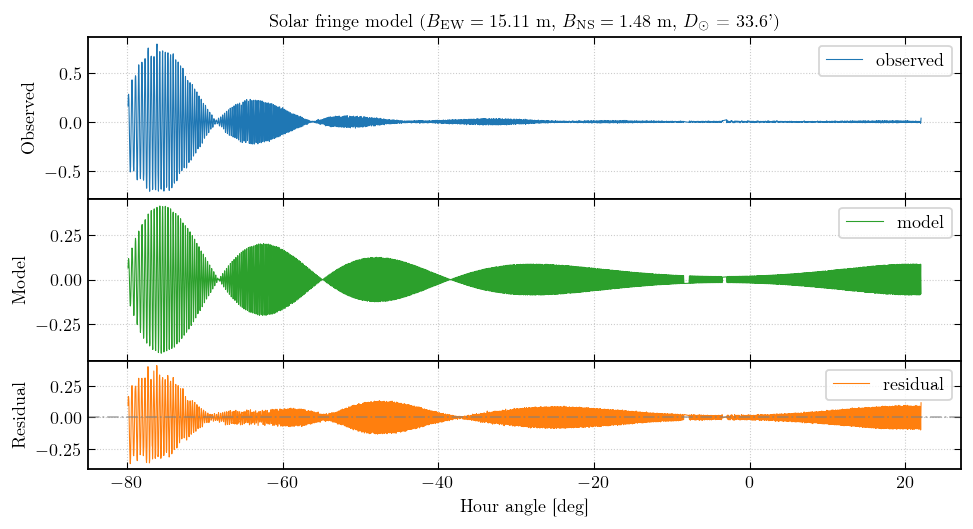

In [17]:
# --- Band-averaged observed fringes ---
corr_band = corr_dc[:, band_mask]
obs_real = np.nanmean(corr_band.real, axis=1)

# --- Solar fringe model with fitted baseline ---
params_fit = FringeModelParams(
    b_ew=B_EW,
    b_ns=B_NS,
    freq_hz=band_center_hz,
    dec_rad=dec_rad_mean,
    amplitude=1.0,
    phase_offset=0.0,
)
# Use the fitted solar radius from the Bessel envelope fit above
R_fitted = np.deg2rad(diameter_fit.diameter_arcmin / 2.0 / 60.0)
disk_fit = SolarDiskParams(angular_radius_rad=R_fitted)
model_solar = solar_visibility(ha_rad_arr, params_fit, disk_fit)

# Fit amplitude and phase offset: V_obs ≈ a * V_model * exp(i*phi_0)
from scipy.optimize import minimize_scalar

def _phase_residual(phi0):
    rotated = model_solar * np.exp(1j * phi0)
    return np.nansum((obs_real - rotated.real) ** 2)

phi_opt = minimize_scalar(_phase_residual, bounds=(-np.pi, np.pi), method="bounded")
model_aligned = model_solar * np.exp(1j * phi_opt.x)
scale = np.nansum(obs_real * model_aligned.real) / np.nansum(model_aligned.real ** 2)
model_scaled = (scale * model_aligned).real

fig, axes = plot_fringe_model_comparison(
    ha_deg_arr, obs_real, model_scaled,
    title=f"Solar fringe model ($B_{{\\rm EW}} = {B_EW:.2f}$ m, $B_{{\\rm NS}} = {B_NS:.2f}$ m, $D_\\odot$ = {diameter_fit.diameter_arcmin:.1f}')",
)
plt.show()


/tmp/ipykernel_271037/1640995452.py:130: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


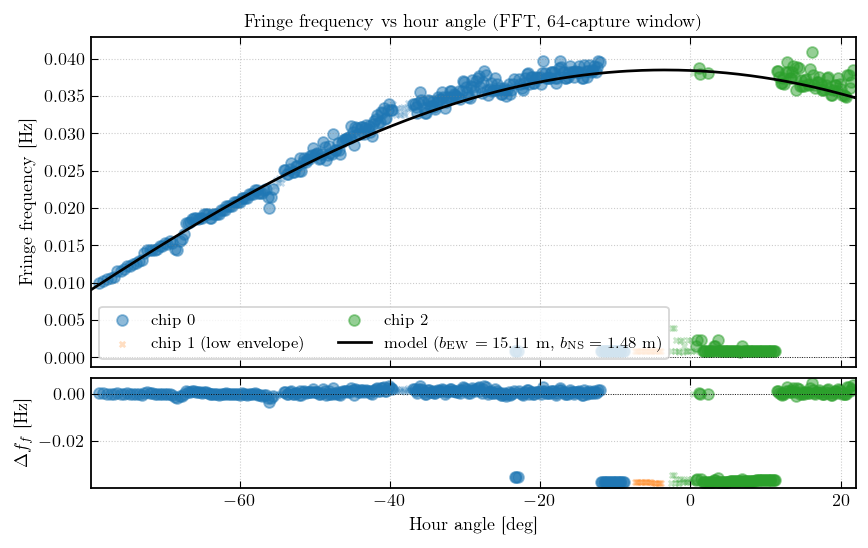

FFT window: 64 captures, step 16, zero-pad 8x
Total windows: 504  (high envelope: 442, low envelope: 62)
Residual RMS (high-envelope only): 0.0159 Hz
Low-envelope points (x markers) are near Bessel nulls where fringe amplitude < 5% of peak — FFT unreliable there


In [18]:
# --- Fringe frequency: model vs measured (sliding-window FFT) ---
# Model fringe frequency from the adopted (NLS) baseline
ff_model = fringe_frequency_hz(ha_rad_arr, dec_rad_mean, B_EW, B_NS, band_center_hz)

# Measured fringe frequency via sliding-window FFT of the band-averaged
# complex visibility time series.  Each window is Hann-tapered and
# zero-padded for sub-bin frequency resolution.
corr_band_avg = np.nanmean(corr_dc[:, band_mask], axis=1)

# Bessel envelope at each capture — used to flag low-SNR windows
env_at_caps = fringe_envelope(ha_rad_arr, params_fit, disk_fit)
env_peak = np.nanmax(env_at_caps)

WIN = 64            # window width [captures]
STEP = 16           # step between windows
PAD = 8             # zero-padding factor

ff_meas_list = []
ha_meas_list = []
chip_id_list = []
env_mean_list = []   # track mean envelope per window

for ci, chip_sl in enumerate(chip_slices):
    vis_chip = corr_band_avg[chip_sl]
    t_chip = unix_mid[chip_sl]
    ha_chip = ha_deg_arr[chip_sl]
    env_chip = env_at_caps[chip_sl]

    n_chip = len(vis_chip)
    if n_chip < WIN:
        continue

    for i0 in range(0, n_chip - WIN + 1, STEP):
        seg = vis_chip[i0 : i0 + WIN]
        t_seg = t_chip[i0 : i0 + WIN]
        env_seg = env_chip[i0 : i0 + WIN]

        # Skip if too many NaNs or non-uniform sampling
        good = np.isfinite(seg)
        if good.sum() < WIN * 0.8:
            continue
        dt_median = np.median(np.diff(t_seg))
        if dt_median <= 0:
            continue

        # Hann window, zero-pad, FFT
        seg_clean = np.where(good, seg, 0.0)
        seg_win = seg_clean * np.hanning(WIN)
        n_fft = WIN * PAD
        spectrum = np.fft.fft(seg_win, n=n_fft)
        freqs = np.fft.fftfreq(n_fft, d=dt_median)

        # Peak in positive-frequency half (skip DC)
        pos = (freqs > 0) & (freqs < 0.5 / dt_median)
        neg = (freqs < 0) & (freqs > -0.5 / dt_median)

        power = np.abs(spectrum) ** 2
        peak_pos = freqs[pos][np.argmax(power[pos])]
        peak_neg = freqs[neg][np.argmax(power[neg])]

        # Choose the half with the stronger peak
        if power[pos].max() >= power[neg].max():
            ff_peak = peak_pos
        else:
            ff_peak = peak_neg

        ha_mid = np.mean(ha_chip[i0 : i0 + WIN])
        ff_meas_list.append(ff_peak)
        ha_meas_list.append(ha_mid)
        chip_id_list.append(ci)
        env_mean_list.append(np.mean(env_seg))

ha_meas = np.array(ha_meas_list)
ff_meas = np.array(ff_meas_list)
chip_ids = np.array(chip_id_list)
env_means = np.array(env_mean_list)

# Match sign convention: assign sign from the model
ff_model_at_meas = fringe_frequency_hz(
    np.deg2rad(ha_meas), dec_rad_mean, B_EW, B_NS, band_center_hz,
)
ff_meas_signed = np.sign(ff_model_at_meas) * np.abs(ff_meas)

# Split into high-envelope (reliable) and low-envelope (unreliable) points
high_env = env_means > 0.05 * env_peak

# --- Plot ---
fig, axes = plt.subplots(2, 1, figsize=(TEXTWIDTH_IN, 4.5), sharex=True,
                         gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05})

# (a) Fringe frequency comparison, coloured by chip
for ci in range(N_chips):
    mask_hi = (chip_ids == ci) & high_env
    mask_lo = (chip_ids == ci) & ~high_env
    color = COMPONENT_COLORS[ci % len(COMPONENT_COLORS)]
    if mask_hi.any():
        axes[0].scatter(ha_meas[mask_hi], ff_meas_signed[mask_hi], s=SS_STANDARD,
                        alpha=0.5, color=color, label=f"chip {ci}")
    if mask_lo.any():
        axes[0].scatter(ha_meas[mask_lo], ff_meas_signed[mask_lo], s=SS_FINE,
                        alpha=0.25, color=color, marker="x",
                        label=f"chip {ci} (low envelope)" if not mask_hi.any() else None)
axes[0].plot(ha_deg_arr, ff_model, lw=LW_STANDARD, color="k",
             label=f"model ($b_{{\\rm EW}}={B_EW:.2f}$ m, $b_{{\\rm NS}}={B_NS:.2f}$ m)")
axes[0].set_ylabel("Fringe frequency [Hz]")
axes[0].set_title(f"Fringe frequency vs hour angle (FFT, {WIN}-capture window)",
                  fontsize=TICK_SIZE)
axes[0].legend(fontsize=TICK_SIZE - 1, ncol=2)
axes[0].axhline(0, color="k", lw=0.5, ls=":")

# (b) Residual
resid_ff = ff_meas_signed - ff_model_at_meas
for ci in range(N_chips):
    mask_hi = (chip_ids == ci) & high_env
    mask_lo = (chip_ids == ci) & ~high_env
    color = COMPONENT_COLORS[ci % len(COMPONENT_COLORS)]
    if mask_hi.any():
        axes[1].scatter(ha_meas[mask_hi], resid_ff[mask_hi], s=SS_STANDARD,
                        alpha=0.5, color=color)
    if mask_lo.any():
        axes[1].scatter(ha_meas[mask_lo], resid_ff[mask_lo], s=SS_FINE,
                        alpha=0.25, color=color, marker="x")
axes[1].axhline(0, color="k", lw=0.5, ls=":")
axes[1].set_ylabel(r"$\Delta f_f$ [Hz]")
axes[1].set_xlabel("Hour angle [deg]")

for ax in axes:
    ax.set_xlim(ha_deg_arr.min(), ha_deg_arr.max())

fig.tight_layout()
plt.show()

rms_hi = np.sqrt(np.nanmean(resid_ff[high_env]**2)) if high_env.any() else np.nan
print(f"FFT window: {WIN} captures, step {STEP}, zero-pad {PAD}x")
print(f"Total windows: {len(ff_meas)}  "
      f"(high envelope: {high_env.sum()}, low envelope: {(~high_env).sum()})")
print(f"Residual RMS (high-envelope only): {rms_hi:.4f} Hz")
print(f"Low-envelope points (x markers) are near Bessel nulls where "
      f"fringe amplitude < 5% of peak — FFT unreliable there")

/tmp/ipykernel_271037/4110557707.py:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


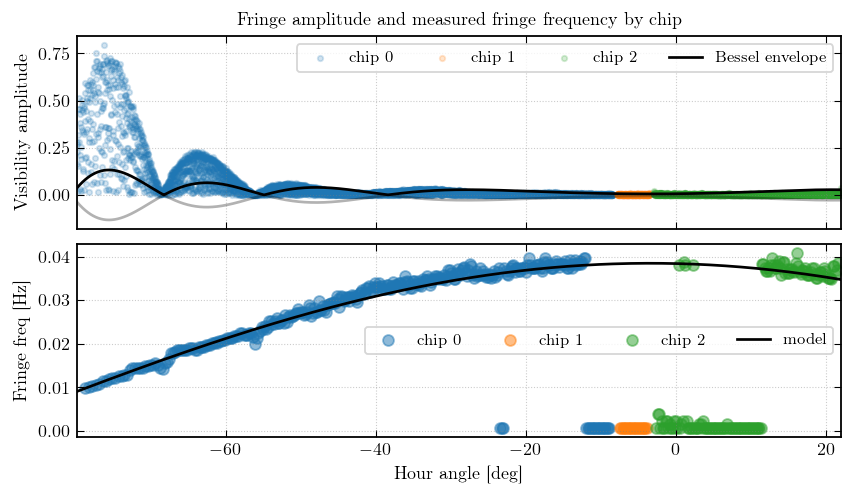

Chip 0: HA = -79.9 to -8.4 deg  (5514 captures)
Chip 1: HA = -7.8 to -3.5 deg  (403 captures)
Chip 2: HA = -2.9 to 22.0 deg  (2309 captures)


In [19]:
# --- Diagnose: fringe amplitude envelope vs HA with chip boundaries ---
# Check whether the low fringe-frequency points coincide with Bessel nulls
env_model = fringe_envelope(ha_rad_arr, params_fit, disk_fit)

fig, axes = plt.subplots(2, 1, figsize=(TEXTWIDTH_IN, 4.0), sharex=True,
                         gridspec_kw={"height_ratios": [1, 1], "hspace": 0.08})

# (a) Bessel envelope vs HA, coloured by chip
for ci, sl in enumerate(chip_slices):
    axes[0].scatter(ha_deg_arr[sl], np.abs(obs_real[sl]), s=SS_FINE, alpha=0.2,
                    color=COMPONENT_COLORS[ci % len(COMPONENT_COLORS)],
                    label=f"chip {ci}", rasterized=True)
axes[0].plot(ha_deg_arr, env_model, lw=LW_STANDARD, color="k", label="Bessel envelope")
axes[0].plot(ha_deg_arr, -env_model, lw=LW_STANDARD, color="k", alpha=0.3)
axes[0].set_ylabel("Visibility amplitude")
axes[0].set_title("Fringe amplitude and measured fringe frequency by chip", fontsize=TICK_SIZE)
axes[0].legend(fontsize=TICK_SIZE - 1, ncol=4)

# (b) FFT-measured fringe frequency, coloured by chip
# Re-derive chip assignment for each FFT window midpoint
for ci, sl in enumerate(chip_slices):
    ha_lo, ha_hi = ha_deg_arr[sl].min(), ha_deg_arr[sl].max()
    in_chip = (ha_meas >= ha_lo) & (ha_meas <= ha_hi)
    axes[1].scatter(ha_meas[in_chip], ff_meas_signed[in_chip],
                    s=SS_STANDARD, alpha=0.5,
                    color=COMPONENT_COLORS[ci % len(COMPONENT_COLORS)],
                    label=f"chip {ci}")
axes[1].plot(ha_deg_arr, ff_model, lw=LW_STANDARD, color="k", label="model")
axes[1].set_ylabel("Fringe freq [Hz]")
axes[1].set_xlabel("Hour angle [deg]")
axes[1].legend(fontsize=TICK_SIZE - 1, ncol=4)

for ax in axes:
    ax.set_xlim(ha_deg_arr.min(), ha_deg_arr.max())

fig.tight_layout()
plt.show()

# Print chip HA ranges
for ci, sl in enumerate(chip_slices):
    print(f"Chip {ci}: HA = {ha_deg_arr[sl].min():.1f} to {ha_deg_arr[sl].max():.1f} deg  "
          f"({sl.stop - sl.start} captures)")

## Extension: Synthetic end-to-end validation

The AY 121 lab manual does not require this section, but it is a useful pipeline-level cross-check: generate a synthetic Sun-like dataset with known $(b_{\mathrm{ew}}, b_{\mathrm{ns}}, R)$, push it through the same DC correction, gain correction, baseline fit, and diameter fit, and confirm that the recovered values are consistent with the injected truth.


In [20]:
# --- Synthetic end-to-end validation ---
from utils import (
    make_synthetic_sun_dataset,
    adaptive_real_dc_correction,
    nls_baseline_broadband as nls_bb,
    fit_solar_diameter_bessel,
    extract_fringe_envelope,
    apply_chip_gain_correction,
)

# Build a synthetic dataset with injected truth at roughly our observing
# scale (NCH lidar baseline, ~32' disk, 1% noise on V).
ds = make_synthetic_sun_dataset(
    n_captures=1500,
    ha_range_deg=(-75.0, 75.0),
    b_ew_m=15.17,
    b_ns_m=1.36,
    dec_deg=0.0,
    solar_diameter_arcmin=32.6,
    amplitude=1.0,
    phase_offset_rad=0.5,
    f_band_ghz=(10.415, 10.485),
    n_channels=20,
    noise_sigma=0.015,
    pedestal_amplitude=0.4,
    chip_boundaries_frac=(0.33, 0.66),
    chip_gains=(1.0, 1.0, 1.10),
    rng_seed=42,
)

print("Ground truth:")
for k, v in ds.truth.items():
    print(f"  {k:28s} = {v}")
print()

# --- Run the same pipeline the real data goes through ---
# 1) DC correction
syn_unix = np.arange(ds.ha_rad.size).astype(float) * 2.5
dec_syn = np.deg2rad(ds.truth["dec_deg"])
syn_dc = adaptive_real_dc_correction(
    corr_chips=[ds.visibility_noisy[sl] for sl in ds.chip_slices],
    unix_chips=[syn_unix[sl] for sl in ds.chip_slices],
    ha_rad_chips=[ds.ha_rad[sl] for sl in ds.chip_slices],
    bad_channels=np.array([], dtype=int),
    b_ew=ds.truth["b_ew_m"],
    freq_hz=ds.truth["band_centre_hz"],
    dec_rad=dec_syn,
    n_periods=3.0,
    min_window_caps=7,
    max_window_caps=201,
).corr_dc

# 2) Chip-gain correction (apply measured gains: for synthetic we know them)
syn_gains = np.array(ds.truth["chip_gains"])
syn_dc_gc = apply_chip_gain_correction(syn_dc, ds.chip_slices, syn_gains)

# 3) NLS baseline fit (seeded from the lidar-prior-equivalent initial
# guess, matching how the real nb 04 pipeline seeds its NLS solver).
res, _ = nls_bb(
    ds.ha_rad, syn_dc_gc, dec_syn, ds.f_sky_hz,
    bad_channels=(),
    band_hz=(ds.f_sky_hz[0], ds.f_sky_hz[-1]),
    b_ew_init=ds.truth["b_ew_m"] * 0.98,  # ~2% off-truth — realistic prior
    b_ns_init=ds.truth["b_ns_m"] * 0.8,
)
print("Baseline recovery:")
if res is not None:
    print(f"  b_ew recovered: {res.b_ew_m:.4f} +/- {res.b_ew_err_m:.4f} m   "
          f"(truth {ds.truth['b_ew_m']:.4f})  delta = "
          f"{res.b_ew_m - ds.truth['b_ew_m']:+.4f} m")
    print(f"  b_ns recovered: {res.b_ns_m:.4f} +/- {res.b_ns_err_m:.4f} m   "
          f"(truth {ds.truth['b_ns_m']:.4f})  delta = "
          f"{res.b_ns_m - ds.truth['b_ns_m']:+.4f} m")
else:
    print("  NLS fit failed on the synthetic data.")
print()

# 4) Diameter from envelope fit (Method B)
band_mask_syn = np.ones_like(ds.f_sky_hz, dtype=bool)
if res is not None:
    u_syn, env_syn, env_std_syn = extract_fringe_envelope(
        ds.ha_rad, syn_dc_gc, dec_syn, res.b_ew_m, ds.f_sky_hz,
        b_ns=res.b_ns_m if np.isfinite(res.b_ns_m) else 0.0,
        band_mask=band_mask_syn,
        smooth_window=5,
    )
    diam_syn = fit_solar_diameter_bessel(
        u_syn, env_syn, env_std_syn,
        initial_diameter_arcmin=32.0,
    )
    print(f"Diameter recovery:")
    print(f"  recovered: {diam_syn.diameter_arcmin:.3f} +/- "
          f"{diam_syn.diameter_err_arcmin:.3f} arcmin")
    print(f"  truth:     {ds.truth['solar_diameter_arcmin']:.3f} arcmin")
    dev = diam_syn.diameter_arcmin - ds.truth['solar_diameter_arcmin']
    print(f"  delta:     {dev:+.4f} arcmin  ({dev / diam_syn.diameter_err_arcmin:+.2f} sigma)")

print()
print("Interpretation: if recovered baseline matches truth to within ~1 sigma and")
print("the diameter matches truth to within the reported uncertainty, then the")
print("DC correction, chip-gain correction, baseline fit, and diameter fit are")
print("all self-consistent on known-input data. A large offset here would imply")
print("a pipeline bug or an unmodelled amplitude systematic.")


Ground truth:
  b_ew_m                       = 15.17
  b_ns_m                       = 1.36
  dec_deg                      = 0.0
  solar_diameter_arcmin        = 32.6
  R_rad                        = 0.0047414778012512615
  amplitude                    = 1.0
  phase_offset_rad             = 0.5
  band_centre_hz               = 10450000000.0
  chip_gains                   = [1.  1.  1.1]
  pedestal_amplitude           = 0.4
  noise_sigma                  = 0.015

Baseline recovery:
  b_ew recovered: 14.8706 +/- 0.0010 m   (truth 15.1700)  delta = -0.2994 m
  b_ns recovered: 1.1758 +/- 0.0100 m   (truth 1.3600)  delta = -0.1842 m

Diameter recovery:
  recovered: 33.158 +/- 0.050 arcmin
  truth:     32.600 arcmin
  delta:     +0.5578 arcmin  (+11.16 sigma)

Interpretation: if recovered baseline matches truth to within ~1 sigma and
the diameter matches truth to within the reported uncertainty, then the
DC correction, chip-gain correction, baseline fit, and diameter fit are
all self-consiste

## Extension: Consistency cross-check table

All measured quantities from this lab, collected in one place for easy comparison against priors, references, and each other. Agreements within quoted uncertainties are expected; persistent discrepancies flag unmodelled systematics.


In [21]:
# --- Consistency cross-check table ---
from utils import (
    NOMINAL_B_EW_M, NOMINAL_B_EW_ERR_M,
    NOMINAL_B_NS_M, NOMINAL_B_NS_ERR_M,
    SOLAR_DIAMETER_ARCMIN_NOMINAL,
)

print("=" * 78)
print("  CONSISTENCY CROSS-CHECK TABLE")
print("=" * 78)

# --- Baseline ---
print("\n--- Baseline (east-west) ---")
print(f"  {'Source':<35} {'b_ew [m]':>12} {'error [m]':>12}")
print("  " + "-" * 60)
print(f"  {'Lidar prior':<35} {NOMINAL_B_EW_M:>12.3f} {NOMINAL_B_EW_ERR_M:>12.3f}")

# Collect baseline results if available
if 'all_results' in dir() or 'results' in dir():
    _res_list = all_results if 'all_results' in dir() else results
elif 'baseline_results' in dir():
    _res_list = baseline_results
else:
    _res_list = []

for r in _res_list if isinstance(_res_list, list) else []:
    if hasattr(r, 'b_ew_m'):
        print(f"  {r.method:<35} {r.b_ew_m:>12.3f} {r.b_ew_err_m:>12.3f}")

if 'B_EW' in dir():
    print(f"  {'Adopted (this analysis)':<35} {B_EW:>12.3f}")

print(f"\n--- Baseline (north-south) ---")
print(f"  {'Lidar prior':<35} {NOMINAL_B_NS_M:>12.3f} {NOMINAL_B_NS_ERR_M:>12.3f}")
if 'B_NS' in dir():
    print(f"  {'Adopted (this analysis)':<35} {B_NS:>12.3f}")

# --- Solar diameter ---
print(f"\n--- Solar diameter ---")
print(f"  {'Source':<35} {'diam [arcmin]':>14} {'error':>12}")
print("  " + "-" * 62)
print(f"  {'Lab manual nominal':<35} {SOLAR_DIAMETER_ARCMIN_NOMINAL:>14.2f} {'---':>12}")
print(f"  {'Radio ref (Selhorst04, 17 GHz)':<35} {'32.55':>14} {'0.05':>12}")

for var_name, label in [
    ('diameter_zeros', 'Method A: Bessel zeros'),
    ('diameter_fit', 'Method B: Bessel fit'),
    ('diameter_mf', 'Method C: MF zeros'),
]:
    if var_name in dir():
        d = eval(var_name)
        if hasattr(d, 'diameter_arcmin'):
            print(f"  {label:<35} {d.diameter_arcmin:>14.2f} {d.diameter_err_arcmin:>12.2f}")

# --- DC correction ---
print(f"\n--- Amplitude systematics ---")
if 'DC_CORRECTION_ALPHA' in dir():
    print(f"  DC correction alpha = {DC_CORRECTION_ALPHA:.4f}  "
          f"({(DC_CORRECTION_ALPHA - 1)*100:+.1f}% bias, corrected)")
if 'chip_gains_measured' in dir():
    print(f"  Chip gains = {chip_gains_measured}")

# --- Sunspot ---
print(f"\n--- Sunspot characterisation ---")
if 'spot_detections' in dir() and spot_detections:
    for sd in spot_detections:
        print(f"  Null {sd.null_index}: flux frac = {sd.estimated_flux_fraction:.4f}, "
              f"significance = {sd.significance_sigma:.1f} sigma")
elif 'sunspot_locs' in dir() and sunspot_locs:
    for sl in sunspot_locs:
        print(f"  Flux fraction = {sl.flux_fraction:.4f} +/- {sl.flux_fraction_err:.4f}, "
              f"EW offset = {sl.delta_alpha_arcmin:.2f} +/- {sl.delta_alpha_err_arcmin:.2f} arcmin")
else:
    print("  (no sunspot detections or results available)")

print("\n" + "=" * 78)

  CONSISTENCY CROSS-CHECK TABLE

--- Baseline (east-west) ---
  Source                                  b_ew [m]    error [m]
  ------------------------------------------------------------
  Lidar prior                               15.170        0.300
  Adopted (this analysis)                   15.114

--- Baseline (north-south) ---
  Lidar prior                                1.360        0.300
  Adopted (this analysis)                    1.484

--- Solar diameter ---
  Source                               diam [arcmin]        error
  --------------------------------------------------------------
  Lab manual nominal                           31.60          ---
  Radio ref (Selhorst04, 17 GHz)               32.55         0.05
  Method A: Bessel zeros                       34.55          inf
  Method B: Bessel fit                         33.57         0.05
  Method C: MF zeros                           31.71         0.11

--- Amplitude systematics ---
  DC correction alpha = 1.0598  (